# Inference Recorder Review
This notebook is focused on visually checking what the inference recorder is saving.
It is intentionally exploratory and tolerant to partial runs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    discover_recorder_payloads,
    list_recorder_files,
    load_recorder_payload,
    payload_summary_frame,
    activation_inventory_frame,
    plot_scanpath_overview,
    plot_attention_heatmap,
    plot_sampling_locations,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath')

In [2]:
all_pt_files = list_recorder_files()
display(all_pt_files.head(20))

recorder_files = discover_recorder_payloads(limit=50)
display(recorder_files)

if recorder_files.empty:
    print('No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.')

,file,modified,size_kb
0,outputs\outputs\2026-03-16\15-45-44\inference_records\val_epoch_0005_batch_00054_Fixation.pt,2026-03-16 14:59:26.218614817,6858.8
1,outputs\outputs\2026-03-16\15-45-44\inference_records\train_epoch_0005_batch_00164_step_000824_Fixation.pt,2026-03-16 14:59:26.148909330,10704.2
2,outputs\outputs\2026-03-16\15-32-24\inference_records\val_epoch_0005_batch_00054_Denoise.pt,2026-03-16 14:59:17.728081703,10712.9
3,outputs\outputs\2026-03-16\15-32-24\inference_records\train_epoch_0005_batch_00164_step_000824_Denoise.pt,2026-03-16 14:59:17.624658108,2626.5


,file,split,phase,epoch,batch_index,global_step,modified,size_kb
0,outputs\outputs\2026-03-16\15-45-44\inference_records\val_epoch_0005_batch_00054_Fixation.pt,val,Fixation,5,54,NaN,2026-03-16 14:59:26.218614817,6858.8
1,outputs\outputs\2026-03-16\15-45-44\inference_records\train_epoch_0005_batch_00164_step_000824_Fixation.pt,train,Fixation,5,164,824.0,2026-03-16 14:59:26.148909330,10704.2
2,outputs\outputs\2026-03-16\15-32-24\inference_records\val_epoch_0005_batch_00054_Denoise.pt,val,Denoise,5,54,NaN,2026-03-16 14:59:17.728081703,10712.9
3,outputs\outputs\2026-03-16\15-32-24\inference_records\train_epoch_0005_batch_00164_step_000824_Denoise.pt,train,Denoise,5,164,824.0,2026-03-16 14:59:17.624658108,2626.5


In [3]:
selected_path = None
if not recorder_files.empty:
    selected_path = PROJECT_ROOT / recorder_files.iloc[0]['file']
selected_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-16/15-45-44/inference_records/val_epoch_0005_batch_00054_Fixation.pt')

In [4]:
if selected_path is not None:
    payload = load_recorder_payload(selected_path)
    display(payload.get('metadata', {}))
    display(payload_summary_frame(payload))

{'epoch': 5,
 'phase': 'Fixation',
 'split': 'val',
 'batch_index': 54,
 'global_step': None,
 'model_name': 'MixerModel'}

,section,name,shape,dtype
0,data,sample_idx,"(15,)",torch.int64
1,data,image_idx,"(15,)",torch.int64
2,data,eye_tracking_input,"(15, 13, 3)",torch.float32
3,data,fixation_ground_truth,"(15, 11, 3)",torch.float32
4,outputs,scanpath_coordinates,"(15, 12, 2)",torch.float32
5,outputs,scanpath_duration,"(15, 12, 1)",torch.float32
6,outputs,scanpath_end_logits,"(15, 12, 1)",torch.float32
7,activations,eye_decoder.0.cross_attn.sampling_offsets,"(15, 13, 8, 4, 2)",list
8,activations,eye_decoder.0.cross_attn.attention_weights,"(15, 13, 8, 4)",list
9,activations,eye_decoder.0.cross_attn.sampling_locations,"(15, 13, 8, 4, 2)",list


In [5]:
if selected_path is not None:
    display(activation_inventory_frame(payload).sort_values(['module', 'activation']).reset_index(drop=True))

,module,activation,shape,captures
0,decoder.0.first_cross_attn,attention_weights,"(15, 8, 1, 13)",12
1,decoder.0.second_cross_attn,attention_weights,"(15, 1, 8, 4)",12
2,decoder.0.second_cross_attn,sampling_locations,"(15, 1, 8, 4, 2)",12
3,decoder.0.second_cross_attn,sampling_offsets,"(15, 1, 8, 4, 2)",12
4,decoder.1.first_cross_attn,attention_weights,"(15, 8, 1, 13)",12
5,decoder.1.second_cross_attn,attention_weights,"(15, 1, 8, 4)",12
6,decoder.1.second_cross_attn,sampling_locations,"(15, 1, 8, 4, 2)",12
7,decoder.1.second_cross_attn,sampling_offsets,"(15, 1, 8, 4, 2)",12
8,decoder.2.first_cross_attn,attention_weights,"(15, 8, 1, 13)",12
9,decoder.2.second_cross_attn,attention_weights,"(15, 1, 8, 4)",12


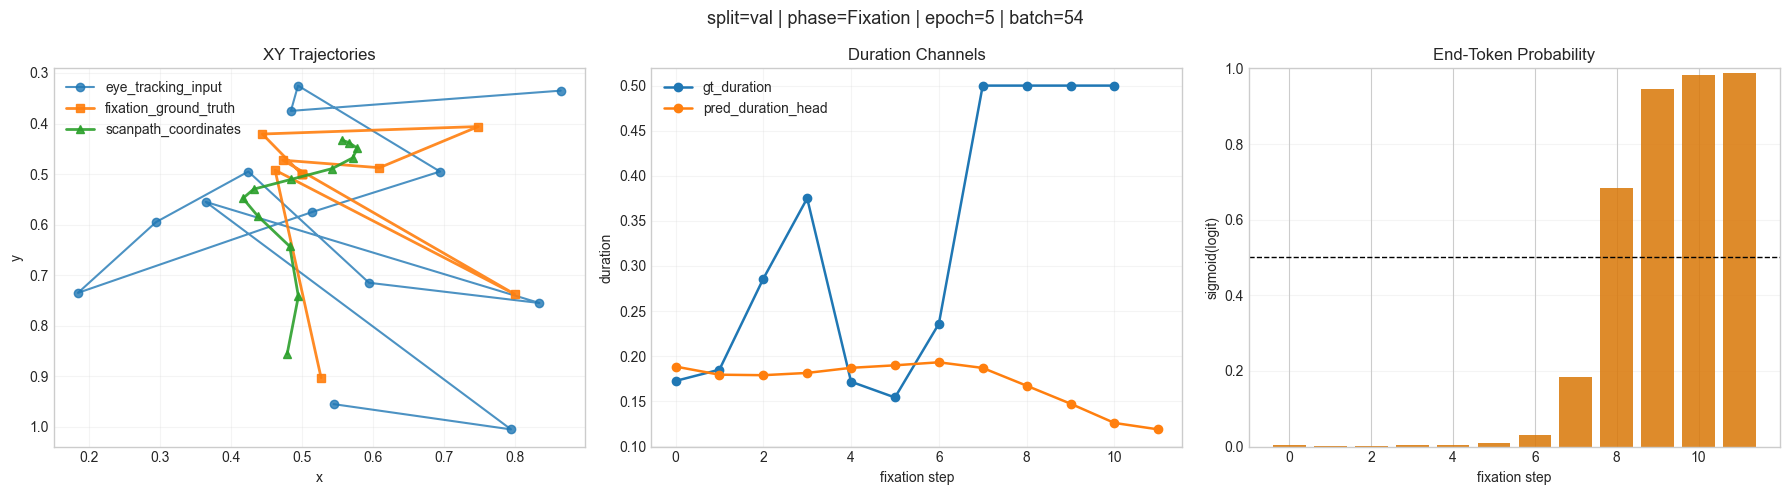

In [6]:
if selected_path is not None:
    plot_scanpath_overview(payload, sample_index=0)

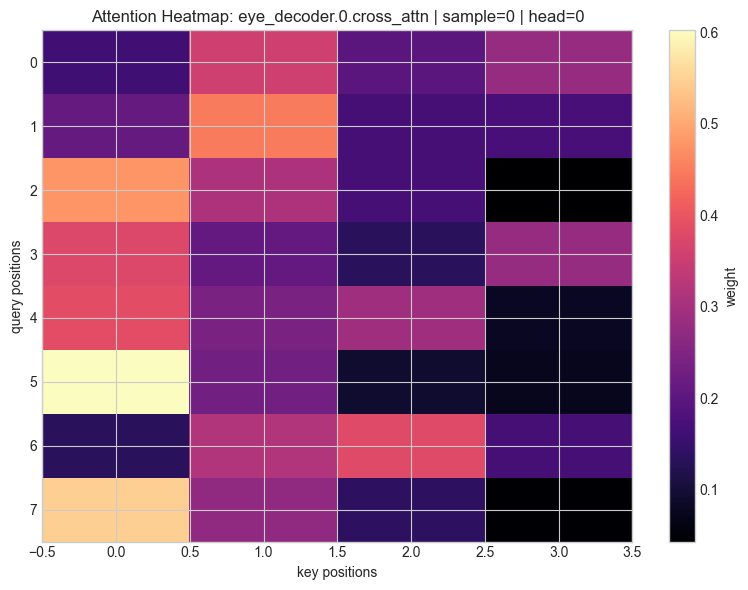

In [7]:
if selected_path is not None:
    try:
        plot_attention_heatmap(payload, sample_index=0, head_index=0)
    except ValueError as exc:
        print(exc)

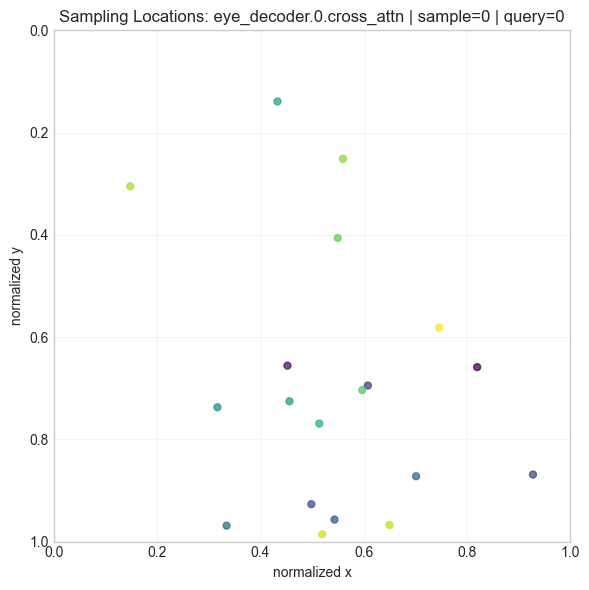

In [8]:
if selected_path is not None:
    try:
        plot_sampling_locations(payload, sample_index=0, query_index=0)
    except ValueError as exc:
        print(exc)

## Notes
- `data` comes from `InferenceRecorder.record_batch` and currently includes indices plus input/target tensors when present.
- `outputs` includes `denoise`, `coord`, `dur`, `reg`, and `cls` under more descriptive names.
- `activations` currently come from attention modules in `blocks.py`, mainly cross-attention weights and deformable-attention sampling tensors.